In [2]:
import sys

sys.path.append("../../v2")
sys.path.append("..")

%load_ext autoreload
%autoreload 2

from pathlib import Path
import re
import numpy as np
import pandas as pd
import polars as pl
from scipy.stats import cumfreq
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,QuantileTransformer


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import numpy as np
from scipy.integrate import odeint
from scipy.constants import G
import matplotlib.pyplot as plt

(3600000, 2)


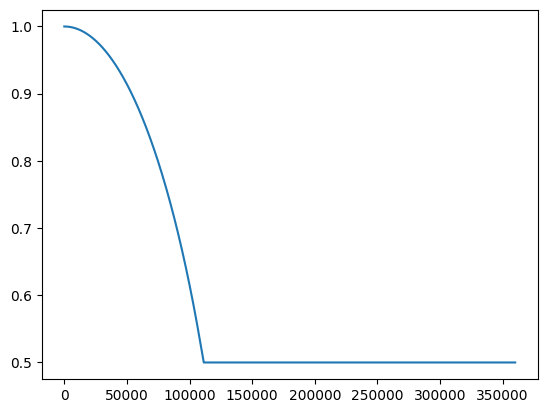

In [ ]:
m1, m2 = 1, 1
r0 = 1


def diff_eq(state, t):
    pos = state[0]
    vel = state[1]
    if pos < 0.5:
        vel = 0
        acc = 0
    else:
        acc = -G * 1 / pos**2
    return vel, acc


t = np.arange(0, 100 * 3600, 1e-1)
y0 = np.array([1, 0])
sol = odeint(diff_eq, y0, t)
print(sol.shape)

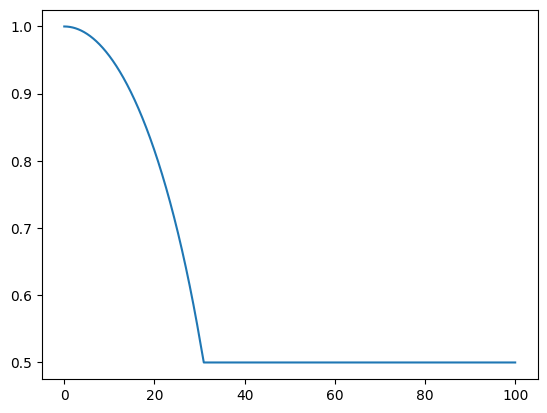

In [ ]:
plt.plot(t / 3600, sol[:, 0])

In [3]:
data_path = Path("/data1/prostrat-ai/data/peptide_and_clinical_data_v2.csv")
full_df = pl.read_csv(data_path)
full_df = full_df.fill_nan(0.0)
full_df = full_df.fill_null(0.0)

In [4]:
peptide_patt = re.compile("peptide", re.IGNORECASE)
peptide_cols = [
    col for col in full_df.columns if re.search(peptide_patt, col) is not None
]
non_peptide = [
    col for col in full_df.columns if col not in peptide_cols + ["idAuswertung"]
]

In [5]:
def split_peptide_columns_by_zero_percentage(
    df: pl.DataFrame, zero_perc_threshold: float = 0.3
):
    total_rows = df.height

    # Calculate zero percentages for all columns at once
    zero_percentages = df.select(
        [(pl.col(col) == 0).sum() / total_rows for col in df.columns]
    ).to_dicts()[0]

    above_zero_threshold = [
        col for col, pct in zero_percentages.items() if pct > zero_perc_threshold
    ]
    below_zero_threshold = [
        col for col, pct in zero_percentages.items() if pct <= zero_perc_threshold
    ]
    return below_zero_threshold, above_zero_threshold

In [6]:
below, above = split_peptide_columns_by_zero_percentage(
    full_df.select(peptide_cols), zero_perc_threshold=0.3
)

In [7]:
high_zero_peptides = full_df.select(above)

In [8]:
low_zero_peptides = full_df.select(below)

In [23]:
low_df = low_zero_peptides.to_pandas()
high_df = high_zero_peptides.to_pandas()

In [22]:
low_df.apply(lambda x: np.histogram(x)[0][0] / len(x))

Peptide_99900214    0.888809
Peptide_99900259    0.784064
Peptide_99900307    0.970994
Peptide_99900340    0.872158
Peptide_99900373    0.924082
                      ...   
Peptide_99920519    0.529633
Peptide_99920622    0.603939
Peptide_99920761    0.836885
Peptide_99920983    0.975291
Peptide_99921380    0.885407
Length: 594, dtype: float64

In [ ]:
def get_most_populated_bit(x: pd.Series):
    counts, bin_edges = np.histogram(x)

In [24]:
high_df.apply(lambda x: np.histogram(x)[0][0] / len(x))

Peptide_99900001    0.998389
Peptide_99900002    0.991047
Peptide_99900003    0.991764
Peptide_99900004    0.996240
Peptide_99900005    0.981558
                      ...   
Peptide_99921555    0.985676
Peptide_99921556    0.992122
Peptide_99921557    0.996061
Peptide_99921558    0.996419
Peptide_99921559    0.999463
Length: 20965, dtype: float64